## 1. Environment setup


In [17]:
import sys
import subprocess
import pkgutil
import warnings
warnings.filterwarnings("ignore")

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "shap": "shap",
    "lime": "lime",
    "joblib": "joblib",
}


def install_if_missing(import_name, pip_name, optional=False):
    if pkgutil.find_loader(import_name) is None:
        try:
            label = "optional package" if optional else "package"
            print(f"Installing missing {label}: {pip_name}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name], timeout=120)
        except Exception as exc:
            if optional:
                print(f"Optional package {pip_name} could not be installed. A safe fallback will be used. Details: {exc}")
            else:
                raise

for import_name, pip_name in REQUIRED_PACKAGES.items():
    install_if_missing(import_name, pip_name, optional=False)


print("Environment check completed.")

Environment check completed.


## 2. Imports and global configuration


In [18]:
import os
import re
import glob
import json
import time
import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

CUSTOM_DATA_PATH = "/kaggle/input/datasets/mohameddarweish/cardiovascular-diseases"

TARGET_COLUMN = "CARDIO_DISEASE"

FAST_MODE = False


USE_BAYESIAN_OPTIMIZATION_IF_AVAILABLE = False

N_SEARCH_ITER = 8 if FAST_MODE else 15
CV_FOLDS = 3

BACKGROUND_SIZE = 80 if FAST_MODE else 120
XAI_SAMPLE_SIZE = 120 if FAST_MODE else 250
PDP_FEATURE_COUNT = 3
TOP_K_XAI_FEATURES = 12

OUTPUT_DIR = Path("rezk_2024_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")
print(f"CUSTOM_DATA_PATH = {CUSTOM_DATA_PATH}")
print(f"TARGET_COLUMN = {TARGET_COLUMN}")
print(f"FAST_MODE = {FAST_MODE}")
print(f"USE_BAYESIAN_OPTIMIZATION_IF_AVAILABLE = {USE_BAYESIAN_OPTIMIZATION_IF_AVAILABLE}")
print(f"N_SEARCH_ITER = {N_SEARCH_ITER}")
print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")


Configuration loaded.
CUSTOM_DATA_PATH = /kaggle/input/datasets/mohameddarweish/cardiovascular-diseases
TARGET_COLUMN = CARDIO_DISEASE
FAST_MODE = False
USE_BAYESIAN_OPTIMIZATION_IF_AVAILABLE = False
N_SEARCH_ITER = 15
Outputs will be saved to: /kaggle/working/rezk_2024_outputs


## 3. Dataset loading and utility helpers


In [19]:
def normalize_name(name):
    """Standardize column names for safer downstream processing."""
    name = str(name).strip().lower()
    name = re.sub(r"[^a-zA-Z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name.upper()


def find_csv_files(base_path):
    """Recursively search for CSV files inside a Kaggle dataset directory."""
    if base_path is None:
        return []
    base_path = Path(base_path)
    if base_path.is_file() and base_path.suffix.lower() == ".csv":
        return [str(base_path)]
    if not base_path.exists():
        return []
    return sorted([str(p) for p in base_path.rglob("*.csv")])


def load_dataset(custom_path=None):
    """Load dataset from the configured Kaggle input directory or a direct CSV path."""
    candidate_paths = []
    if custom_path:
        candidate_paths.append(custom_path)
    candidate_paths.extend(["/kaggle/input", "../input"])

    discovered_csvs = []
    for path in candidate_paths:
        discovered_csvs.extend(find_csv_files(path))

    discovered_csvs = list(dict.fromkeys(discovered_csvs))

    if len(discovered_csvs) == 0:
        raise FileNotFoundError(
            "No CSV dataset was found. Please verify CUSTOM_DATA_PATH or attach the dataset to Kaggle."
        )

    print("Detected CSV files:")
    for idx, csv_path in enumerate(discovered_csvs, start=1):
        print(f"{idx}. {csv_path}")

    data_path = discovered_csvs[0]
    print(f"\nUsing dataset: {data_path}")
    df_loaded = pd.read_csv(data_path)
    return df_loaded, data_path


df_raw, DATA_PATH = load_dataset(CUSTOM_DATA_PATH)

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())

Detected CSV files:
1. /kaggle/input/datasets/mohameddarweish/cardiovascular-diseases/cardiovascular_diseases_processed.csv
2. ../input/datasets/mohameddarweish/cardiovascular-diseases/cardiovascular_diseases_processed.csv

Using dataset: /kaggle/input/datasets/mohameddarweish/cardiovascular-diseases/cardiovascular_diseases_processed.csv

Dataset loaded successfully.
Dataset shape: (68783, 12)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0


## 4. Column cleaning and target detection


In [20]:
df = df_raw.copy()
original_columns = df.columns.tolist()

df.columns = [normalize_name(c) for c in df.columns]
print("Column names were standardized.")
display(pd.DataFrame({"Original": original_columns, "Cleaned": df.columns.tolist()}))

TARGET_COLUMN = globals().get("TARGET_COLUMN", "CARDIO_DISEASE")
TARGET_COLUMN_CLEAN = None

target_candidates = [
    TARGET_COLUMN,
    "CARDIO_DISEASE", "CARDIO", "TARGET", "OUTPUT", "TENYEARCHD",
    "HEARTDISEASE", "HEART_DISEASE", "DISEASE", "NUM", "CLASS", "LABEL"
]
target_candidates = [normalize_name(c) for c in target_candidates]

for candidate in target_candidates:
    if candidate in df.columns:
        TARGET_COLUMN_CLEAN = candidate
        break

if TARGET_COLUMN_CLEAN is None:
    raise ValueError(
        "Target column was not found. Please set TARGET_COLUMN in the configuration cell.\n"
        f"Available columns are: {df.columns.tolist()}"
    )

print(f"Detected target column: {TARGET_COLUMN_CLEAN}")
print("Target distribution:")
display(df[TARGET_COLUMN_CLEAN].value_counts(dropna=False).to_frame("count"))


Column names were standardized.


,Original,Cleaned
0,AGE,AGE
1,GENDER,GENDER
2,HEIGHT,HEIGHT
3,WEIGHT,WEIGHT
4,AP_HIGH,AP_HIGH
5,AP_LOW,AP_LOW
6,CHOLESTEROL,CHOLESTEROL
7,GLUCOSE,GLUCOSE
8,SMOKE,SMOKE
9,ALCOHOL,ALCOHOL


Detected target column: CARDIO_DISEASE
Target distribution:


,count
CARDIO_DISEASE,
0,34742
1,34041


## 5. Exploratory Data Analysis (EDA)


In [21]:
print("=" * 90)
print("DATASET OVERVIEW")
print("=" * 90)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean()
}).sort_values("missing_percent", ascending=False)

print("\nMissing values:")
display(missing_df)

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

DATASET OVERVIEW
Shape: (68783, 12)
Rows: 68,783
Columns: 12
Duplicate rows: 3,820

Data types:


,dtype
AGE,int64
GENDER,int64
HEIGHT,int64
WEIGHT,int64
AP_HIGH,int64
AP_LOW,int64
CHOLESTEROL,int64
GLUCOSE,int64
SMOKE,int64
ALCOHOL,int64



Missing values:


,missing_count,missing_percent
AGE,0,0.0
GENDER,0,0.0
HEIGHT,0,0.0
WEIGHT,0,0.0
AP_HIGH,0,0.0
AP_LOW,0,0.0
CHOLESTEROL,0,0.0
GLUCOSE,0,0.0
SMOKE,0,0.0
ALCOHOL,0,0.0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
AGE,68783.0,53.326781,6.768163,30.0,48.0,54.0,58.0,65.0
GENDER,68783.0,1.348749,0.476578,1.0,1.0,1.0,2.0,2.0
HEIGHT,68783.0,164.361252,8.184850,55.0,159.0,165.0,170.0,250.0
WEIGHT,68783.0,74.121934,14.331392,11.0,65.0,72.0,82.0,200.0
AP_HIGH,68783.0,126.614585,16.763763,60.0,120.0,120.0,140.0,240.0
AP_LOW,68783.0,81.381591,9.676679,40.0,80.0,80.0,90.0,190.0
CHOLESTEROL,68783.0,1.364727,0.678976,1.0,1.0,1.0,2.0,3.0
GLUCOSE,68783.0,1.225986,0.571961,1.0,1.0,1.0,1.0,3.0
SMOKE,68783.0,0.088001,0.283299,0.0,0.0,0.0,0.0,1.0
ALCOHOL,68783.0,0.053632,0.225293,0.0,0.0,0.0,0.0,1.0


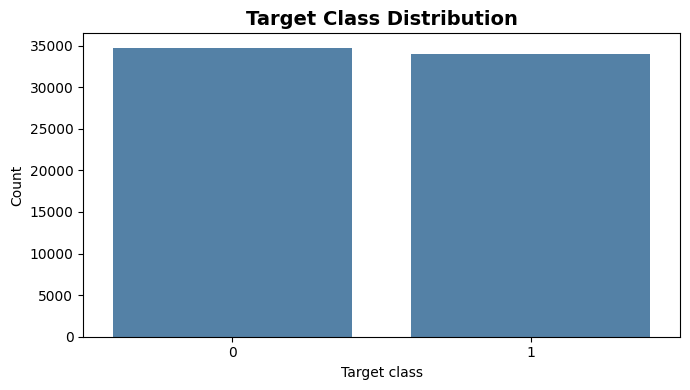

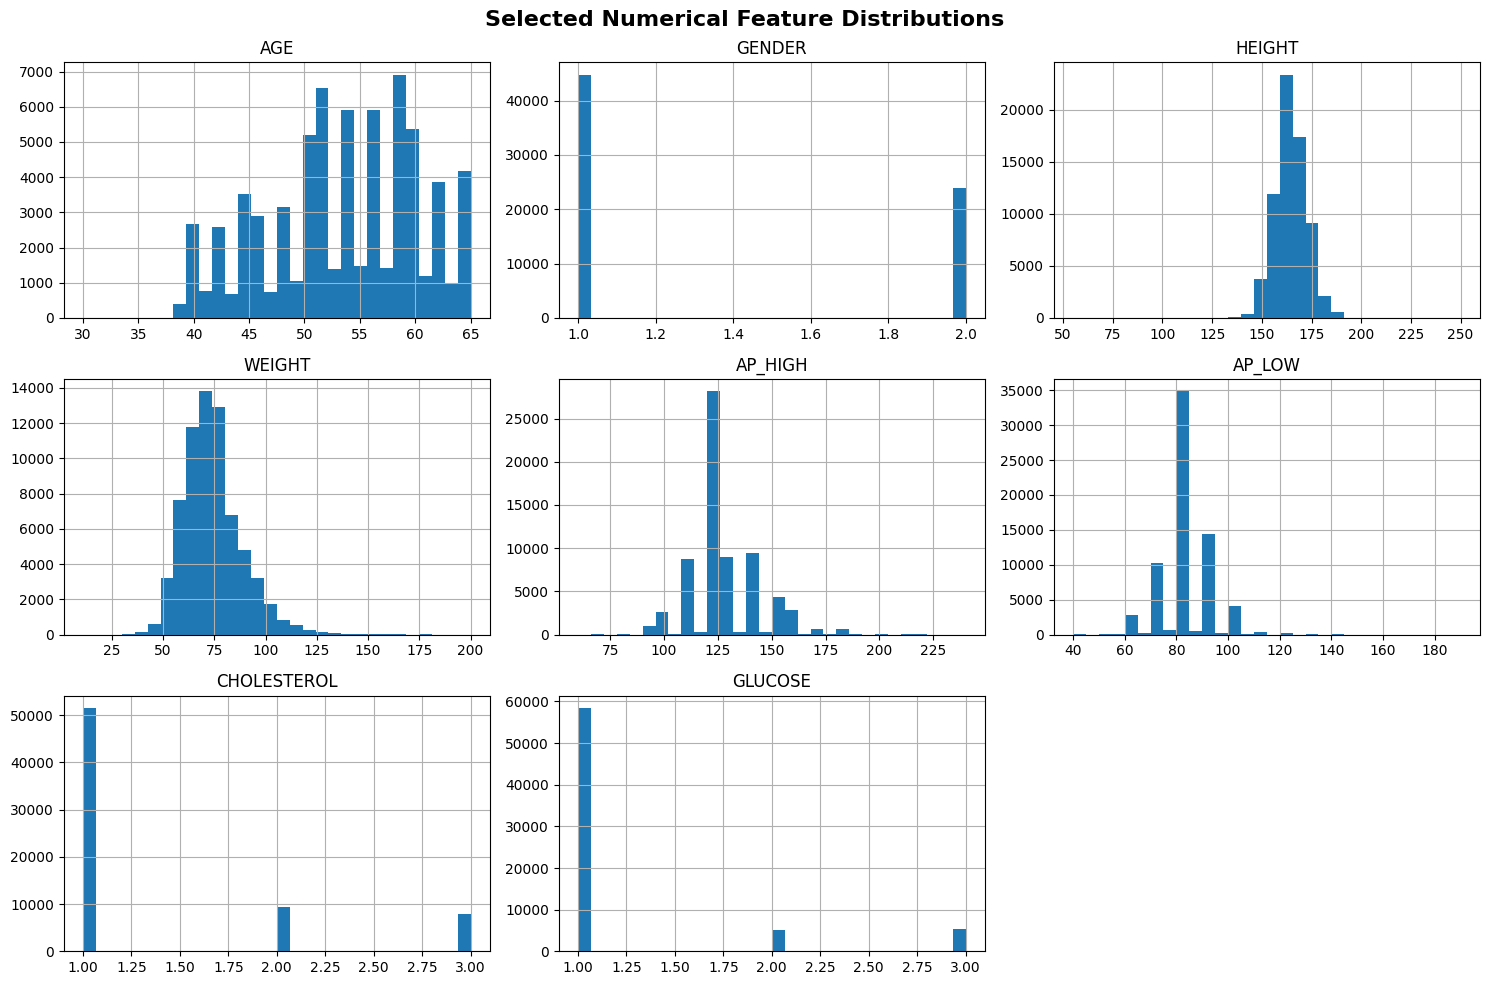

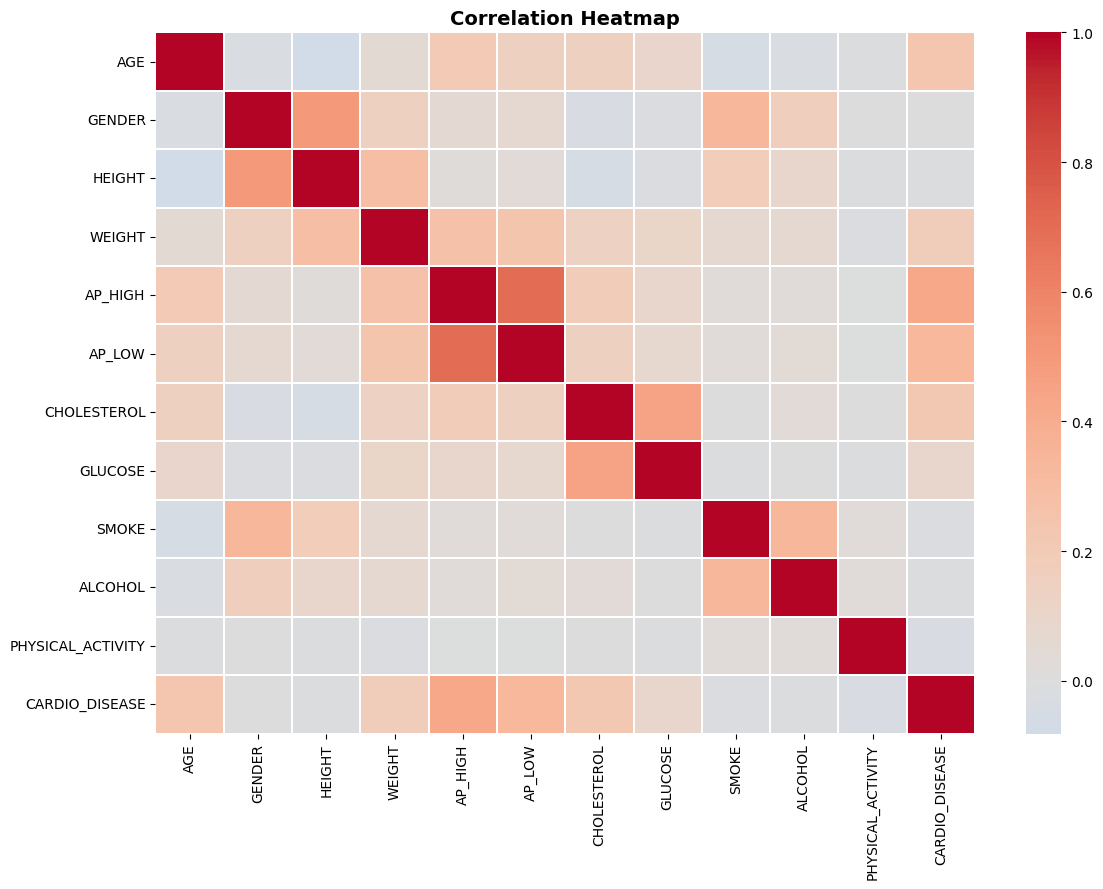

Top numerical correlations with target:


,correlation_with_target
AP_HIGH,0.425109
AP_LOW,0.335067
AGE,0.239133
CHOLESTEROL,0.221517
WEIGHT,0.179680
GLUCOSE,0.090100
PHYSICAL_ACTIVITY,-0.037197
SMOKE,-0.016285
HEIGHT,-0.010752
ALCOHOL,-0.008222


In [22]:
plt.figure(figsize=(7, 4))
sns.countplot(x=TARGET_COLUMN_CLEAN, data=df, color="steelblue")
plt.title("Target Class Distribution", fontsize=14, weight="bold")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

num_cols_for_eda = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COLUMN_CLEAN in num_cols_for_eda:
    num_cols_for_eda.remove(TARGET_COLUMN_CLEAN)

if len(num_cols_for_eda) > 0:
    selected_hist_cols = num_cols_for_eda[: min(8, len(num_cols_for_eda))]
    df[selected_hist_cols].hist(figsize=(15, 10), bins=30)
    plt.suptitle("Selected Numerical Feature Distributions", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "numerical_feature_distributions.png", dpi=200, bbox_inches="tight")
    plt.show()

numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 2:
    plt.figure(figsize=(12, 9))
    corr = numeric_df.corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
    plt.title("Correlation Heatmap", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()

    if TARGET_COLUMN_CLEAN in corr.columns:
        target_corr = corr[TARGET_COLUMN_CLEAN].drop(TARGET_COLUMN_CLEAN).sort_values(key=np.abs, ascending=False)
        print("Top numerical correlations with target:")
        display(target_corr.head(15).to_frame("correlation_with_target"))

## 6. Clinical feature engineering
The Rezk paper focuses on preprocessing, scaling, and optimized ensemble learning. For this our dataset, we also add safe cardiovascular feature engineering when the required columns exist.

Examples:
- **BMI** from height and weight
- **Pulse pressure** from systolic and diastolic pressure
- **Blood pressure ratio**
- **Age-risk interactions**

These engineered features are created only when their source columns are present, so the notebook stays robust across dataset versions.

In [23]:
df_fe = df.copy()
created_features = []

def add_feature_safe(name, values):
    if name not in df_fe.columns:
        df_fe[name] = values
        created_features.append(name)

colset = set(df_fe.columns)

if "AGE" in colset:
    if pd.api.types.is_numeric_dtype(df_fe["AGE"]) and df_fe["AGE"].median() > 130:
        add_feature_safe("AGE_YEARS", df_fe["AGE"] / 365.25)
    else:
        add_feature_safe("AGE_YEARS", df_fe["AGE"])

if {"HEIGHT", "WEIGHT"}.issubset(colset):
    height_m = df_fe["HEIGHT"] / 100.0
    bmi = df_fe["WEIGHT"] / (height_m.replace(0, np.nan) ** 2)
    add_feature_safe("BMI", bmi.replace([np.inf, -np.inf], np.nan))

systolic_candidates = ["AP_HIGH", "SYSTOLIC", "SYSBP", "TRESTBPS", "RESTING_BPS", "RESTINGBP"]
diastolic_candidates = ["AP_LOW", "DIASTOLIC", "DIABP"]

systolic_col = next((c for c in systolic_candidates if c in colset), None)
diastolic_col = next((c for c in diastolic_candidates if c in colset), None)

if systolic_col and diastolic_col:
    add_feature_safe("PULSE_PRESSURE", df_fe[systolic_col] - df_fe[diastolic_col])
    add_feature_safe("BP_RATIO", df_fe[systolic_col] / (df_fe[diastolic_col].replace(0, np.nan) + 1e-6))

if "AGE_YEARS" in df_fe.columns and "BMI" in df_fe.columns:
    add_feature_safe("AGE_BMI_INTERACTION", df_fe["AGE_YEARS"] * df_fe["BMI"])

if systolic_col and "CHOLESTEROL" in colset:
    add_feature_safe("BP_CHOLESTEROL_INTERACTION", df_fe[systolic_col] * df_fe["CHOLESTEROL"])

print(f"Created engineered features: {created_features if created_features else 'No extra features were created because the required columns were not found.'}")
print(f"Shape after feature engineering: {df_fe.shape}")
display(df_fe.head())

Created engineered features: ['AGE_YEARS', 'BMI', 'PULSE_PRESSURE', 'BP_RATIO', 'AGE_BMI_INTERACTION', 'BP_CHOLESTEROL_INTERACTION']
Shape after feature engineering: (68783, 18)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,AGE_YEARS,BMI,PULSE_PRESSURE,BP_RATIO,AGE_BMI_INTERACTION,BP_CHOLESTEROL_INTERACTION
0,50,2,168,62,110,80,1,1,0,0,1,0,50,21.967120,30,1.375000,1098.356009,110
1,55,1,156,85,140,90,3,1,0,0,1,1,55,34.927679,50,1.555556,1921.022354,420
2,52,1,165,64,130,70,3,1,0,0,0,1,52,23.507805,60,1.857143,1222.405877,390
3,48,2,169,82,150,100,1,1,0,0,1,1,48,28.710479,50,1.500000,1378.103008,150
4,48,1,156,56,100,60,1,1,0,0,0,0,48,23.011177,40,1.666667,1104.536489,100


## 7. Train/test split and preprocessing


In [24]:
df_model = df_fe.copy()
df_model = df_model.dropna(subset=[TARGET_COLUMN_CLEAN]).reset_index(drop=True)

id_like_cols = [
    c for c in df_model.columns
    if c != TARGET_COLUMN_CLEAN and c in {"ID", "INDEX", "PATIENT_ID", "SUBJECT_ID", "ROW_ID"}
]
if id_like_cols:
    print(f"Dropping identifier-like columns: {id_like_cols}")
    df_model = df_model.drop(columns=id_like_cols)

X = df_model.drop(columns=[TARGET_COLUMN_CLEAN])
y_raw = df_model[TARGET_COLUMN_CLEAN]

if pd.api.types.is_numeric_dtype(y_raw):
    unique_values = sorted(pd.Series(y_raw.dropna().unique()).tolist())
    if len(unique_values) > 2 and 0 in unique_values:
        print("Target has more than two numeric values. Converting to binary: 0 = no disease, >0 = disease.")
        y_clean = (y_raw.astype(float) > 0).astype(int)
    else:
        y_clean = y_raw.astype(int)
else:
    label_encoder_initial = LabelEncoder()
    y_clean = pd.Series(label_encoder_initial.fit_transform(y_raw.astype(str)), index=y_raw.index)

label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y_clean), name=TARGET_COLUMN_CLEAN)
class_names = [str(c) for c in label_encoder.classes_]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Classes: {class_names}")
display(y.value_counts().sort_index().to_frame("count"))

stratify_arg = y if y.nunique() > 1 else None
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_arg,
)

print(f"Training set: {X_train_raw.shape}")
print(f"Test set: {X_test_raw.shape}")

Feature matrix shape: (68783, 17)
Target shape: (68783,)
Classes: ['0', '1']


,count
CARDIO_DISEASE,
0,34742
1,34041


Training set: (55026, 17)
Test set: (13757, 17)


In [25]:
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_raw.columns if c not in numeric_features]

print(f"Numerical features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

try:
    feature_names = preprocessor.get_feature_names_out().tolist()
except Exception:
    feature_names = numeric_features.copy()
    if categorical_features:
        cat_pipe = preprocessor.named_transformers_.get("cat")
        ohe = cat_pipe.named_steps.get("onehot")
        cat_names = ohe.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train_raw.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)

print("Preprocessing completed.")
print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")
display(X_train_processed.head())

Numerical features: 17
Categorical features: 0
Preprocessing completed.
Processed training shape: (55026, 17)
Processed test shape: (13757, 17)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,AGE_YEARS,BMI,PULSE_PRESSURE,BP_RATIO,AGE_BMI_INTERACTION,BP_CHOLESTEROL_INTERACTION
61337,0.545056,-0.734178,-1.763565,-1.546540,-0.988375,-1.172671,0.934910,-0.394439,-0.310515,-0.23724,0.495532,0.545056,-0.734130,-0.427286,0.070222,-0.401415,0.460699
24795,1.579568,-0.734178,0.196457,0.684614,0.202524,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,1.579568,0.490159,0.391802,0.419299,1.251687,-0.462621
5578,-0.489455,1.362068,0.931465,0.545167,-0.988375,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,-0.489455,0.030869,-1.246373,-1.209725,-0.222562,-0.667803
8198,-1.967329,-0.734178,0.441460,0.196549,-0.988375,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,-1.967329,-0.041526,-1.246373,-1.209725,-0.991226,-0.667803
55351,0.545056,1.362068,-0.661052,-0.709857,-0.392926,-0.142404,-0.537959,-0.394439,-0.310515,-0.23724,0.495532,0.545056,-0.368062,-0.427286,-0.395213,-0.073594,-0.565212


## 8. Rezk-style model definitions

In [26]:
def make_xgb_classifier():
    return XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic" if len(class_names) == 2 else "multi:softprob",
        eval_metric="logloss" if len(class_names) == 2 else "mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def make_lgbm_classifier():
    objective = "binary" if len(class_names) == 2 else "multiclass"
    return LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective=objective,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def make_voting_ensemble(xgb_model=None, lgbm_model=None, weights=(1, 1)):
    if xgb_model is None:
        xgb_model = make_xgb_classifier()
    if lgbm_model is None:
        lgbm_model = make_lgbm_classifier()
    return VotingClassifier(
        estimators=[("xgb", xgb_model), ("lgbm", lgbm_model)],
        voting="soft",
        weights=list(weights),
        n_jobs=1, 
    )

base_models = {
    "XGBoost": make_xgb_classifier(),
    "LightGBM": make_lgbm_classifier(),
    "Soft Voting XGBoost+LightGBM": make_voting_ensemble(),
}

print("Models prepared:")
for model_name in base_models:
    print(f"- {model_name}")

Models prepared:
- XGBoost
- LightGBM
- Soft Voting XGBoost+LightGBM


## 9. Evaluation helper functions


In [27]:
def safe_predict_proba(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)
    preds = model.predict(X_data)
    out = np.zeros((len(preds), len(np.unique(preds))))
    for i, p in enumerate(preds):
        out[i, int(p)] = 1
    return out


def evaluate_model(model, X_eval, y_eval, model_name="model"):
    y_pred = model.predict(X_eval)
    y_proba = safe_predict_proba(model, X_eval)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision_weighted": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_eval, y_pred, average="weighted", zero_division=0),
    }

    if len(class_names) == 2:
        positive_scores = y_proba[:, 1]
        metrics["ROC_AUC"] = roc_auc_score(y_eval, positive_scores)
        metrics["Average_Precision"] = average_precision_score(y_eval, positive_scores)
    else:
        metrics["ROC_AUC_OVR"] = roc_auc_score(y_eval, y_proba, multi_class="ovr", average="weighted")

    return metrics


def plot_confusion_matrix(model, X_eval, y_eval, title, filename):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=13, weight="bold")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


def plot_roc_pr_curves(model, X_eval, y_eval, model_name, prefix):
    if len(class_names) != 2:
        print("ROC/PR plotting in this helper is configured for binary classification only. Skipping.")
        return
    y_proba = safe_predict_proba(model, X_eval)[:, 1]

    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}", fontsize=13, weight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{prefix}_roc_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    precision, recall, _ = precision_recall_curve(y_eval, y_proba)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {model_name}", fontsize=13, weight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{prefix}_precision_recall_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

## 10. Baseline model comparison


In [28]:
baseline_results = []
fitted_baseline_models = {}

for name, model in base_models.items():
    print("=" * 90)
    print(f"Training: {name}")
    start = time.time()
    model.fit(X_train_processed, y_train)
    elapsed = time.time() - start
    metrics = evaluate_model(model, X_test_processed, y_test, model_name=name)
    metrics["Training_time_sec"] = elapsed
    baseline_results.append(metrics)
    fitted_baseline_models[name] = model
    print(f"Done in {elapsed:.2f} seconds")
    display(pd.DataFrame([metrics]))

baseline_results_df = pd.DataFrame(baseline_results).sort_values("F1_weighted", ascending=False)
display(baseline_results_df)
baseline_results_df.to_csv(OUTPUT_DIR / "baseline_model_comparison.csv", index=False)

Training: XGBoost
Done in 0.62 seconds


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Average_Precision,Training_time_sec
0,XGBoost,0.732064,0.733777,0.732064,0.731374,0.799234,0.781252,0.617021


Training: LightGBM
Done in 1.09 seconds


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Average_Precision,Training_time_sec
0,LightGBM,0.730028,0.731359,0.730028,0.72946,0.797459,0.777313,1.092751


Training: Soft Voting XGBoost+LightGBM
Done in 1.71 seconds


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Average_Precision,Training_time_sec
0,Soft Voting XGBoost+LightGBM,0.730319,0.731901,0.730319,0.729664,0.798935,0.780522,1.709073


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Average_Precision,Training_time_sec
0,XGBoost,0.732064,0.733777,0.732064,0.731374,0.799234,0.781252,0.617021
2,Soft Voting XGBoost+LightGBM,0.730319,0.731901,0.730319,0.729664,0.798935,0.780522,1.709073
1,LightGBM,0.730028,0.731359,0.730028,0.729460,0.797459,0.777313,1.092751


## 11. Hyperparameter optimization for the voting ensemble


In [29]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

voting_model_for_search = make_voting_ensemble()


def make_randomized_search():
    """Stable Kaggle-safe hyperparameter search for the Rezk-style soft voting ensemble."""
    param_distributions = {
        "xgb__n_estimators": [150, 250, 350, 500],
        "xgb__max_depth": [2, 3, 4, 5, 6, 7],
        "xgb__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10, 0.15],
        "xgb__subsample": [0.75, 0.85, 0.95, 1.0],
        "xgb__colsample_bytree": [0.75, 0.85, 0.95, 1.0],
        "xgb__reg_lambda": [0.1, 0.5, 1.0, 2.0, 5.0],
        "lgbm__n_estimators": [150, 250, 350, 500, 600],
        "lgbm__num_leaves": [15, 31, 45, 63],
        "lgbm__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.10, 0.15],
        "lgbm__subsample": [0.75, 0.85, 0.95, 1.0],
        "lgbm__colsample_bytree": [0.75, 0.85, 0.95, 1.0],
        "lgbm__reg_lambda": [0.1, 0.5, 1.0, 2.0, 5.0],
        "weights": [(1, 1), (2, 1), (1, 2)],
    }

    return RandomizedSearchCV(
        estimator=make_voting_ensemble(),
        param_distributions=param_distributions,
        n_iter=N_SEARCH_ITER,
        scoring="f1_weighted",
        cv=cv,
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True,
        error_score="raise",
    )


search_method = "RandomizedSearchCV"
search = make_randomized_search()

if USE_BAYESIAN_OPTIMIZATION_IF_AVAILABLE:
    try:
        from skopt import BayesSearchCV
        from skopt.space import Integer, Real

        bayes_search_spaces = {
            "xgb__n_estimators": Integer(150, 500),
            "xgb__max_depth": Integer(2, 7),
            "xgb__learning_rate": Real(0.01, 0.20, prior="log-uniform"),
            "xgb__subsample": Real(0.70, 1.00),
            "xgb__colsample_bytree": Real(0.70, 1.00),
            "xgb__reg_lambda": Real(0.10, 5.00, prior="log-uniform"),
            "lgbm__n_estimators": Integer(150, 600),
            "lgbm__num_leaves": Integer(15, 63),
            "lgbm__learning_rate": Real(0.01, 0.20, prior="log-uniform"),
            "lgbm__subsample": Real(0.70, 1.00),
            "lgbm__colsample_bytree": Real(0.70, 1.00),
            "lgbm__reg_lambda": Real(0.10, 5.00, prior="log-uniform"),
        }

        search = BayesSearchCV(
            estimator=make_voting_ensemble(weights=(1, 1)),
            search_spaces=bayes_search_spaces,
            n_iter=N_SEARCH_ITER,
            scoring="f1_weighted",
            cv=cv,
            n_jobs=1,
            random_state=RANDOM_STATE,
            verbose=1,
            refit=True,
        )
        search_method = "BayesSearchCV without weights optimization"
    except Exception as exc:
        print(f"Bayesian search could not be initialized. Falling back to RandomizedSearchCV. Details: {exc}")
        search_method = "RandomizedSearchCV fallback"
        search = make_randomized_search()

print(f"Search method: {search_method}")

try:
    search.fit(X_train_processed, y_train)
except Exception as exc:
    print(f"{search_method} failed during fit: {exc}")
    print("Falling back to stable RandomizedSearchCV.")
    search_method = "RandomizedSearchCV fallback after failed search"
    search = make_randomized_search()
    search.fit(X_train_processed, y_train)

best_full_model = search.best_estimator_
print("Best CV score:", search.best_score_)
print("Best parameters:")
print(search.best_params_)

pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head(10).to_csv(
    OUTPUT_DIR / "hyperparameter_search_top_results.csv", index=False
)

print("best_full_model is now defined and ready for evaluation/XAI cells.")


Search method: RandomizedSearchCV
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CV score: 0.7351081563551106
Best parameters:
{'xgb__subsample': 0.95, 'xgb__reg_lambda': 0.5, 'xgb__n_estimators': 500, 'xgb__max_depth': 2, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0, 'weights': (1, 1), 'lgbm__subsample': 0.85, 'lgbm__reg_lambda': 5.0, 'lgbm__num_leaves': 15, 'lgbm__n_estimators': 150, 'lgbm__learning_rate': 0.05, 'lgbm__colsample_bytree': 0.85}
best_full_model is now defined and ready for evaluation/XAI cells.


## 12. Final full-feature voting ensemble evaluation


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Average_Precision
0,Rezk Voting Ensemble — Full Features,0.7325,0.734011,0.7325,0.731881,0.799852,0.782932


Classification report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6949
           1       0.75      0.69      0.72      6808

    accuracy                           0.73     13757
   macro avg       0.73      0.73      0.73     13757
weighted avg       0.73      0.73      0.73     13757



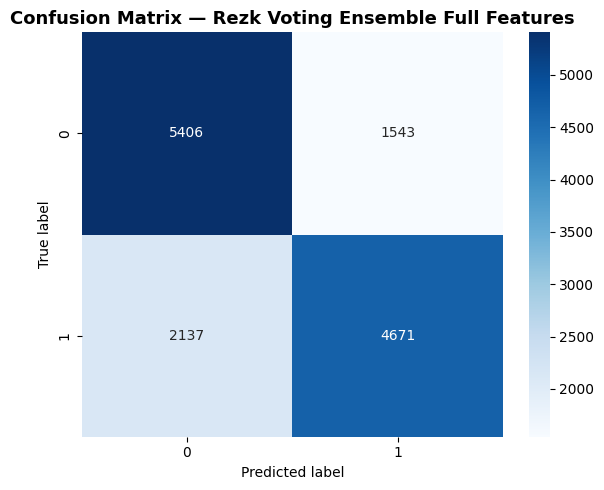

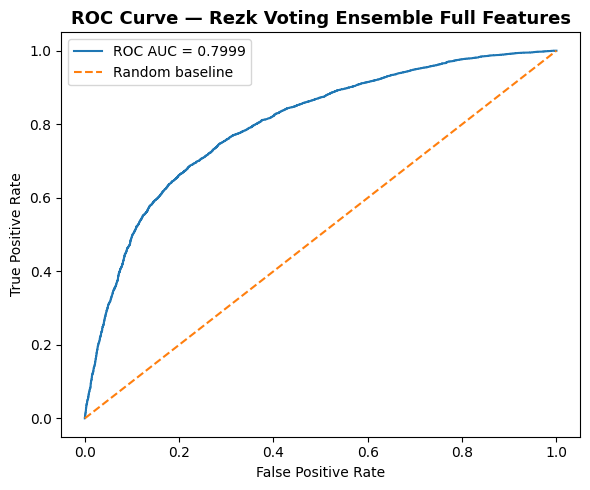

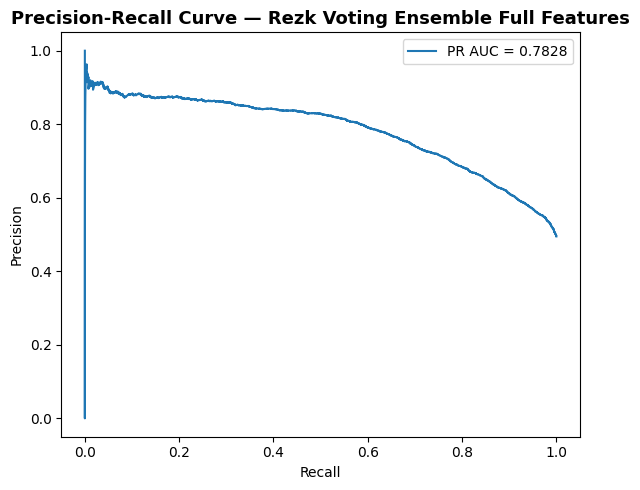

In [30]:
full_model_metrics = evaluate_model(best_full_model, X_test_processed, y_test, model_name="Rezk Voting Ensemble — Full Features")
display(pd.DataFrame([full_model_metrics]))

print("Classification report:")
print(classification_report(y_test, best_full_model.predict(X_test_processed), target_names=class_names, zero_division=0))

plot_confusion_matrix(
    best_full_model,
    X_test_processed,
    y_test,
    title="Confusion Matrix — Rezk Voting Ensemble Full Features",
    filename="full_voting_confusion_matrix.png",
)
plot_roc_pr_curves(
    best_full_model,
    X_test_processed,
    y_test,
    model_name="Rezk Voting Ensemble Full Features",
    prefix="full_voting",
)

## 13. XAI technique 1 — SHAP for the voting ensemble

SHAP background shape: (120, 17)
SHAP explanation sample shape: (250, 17)
Using max_evals=101 for SHAP permutation explanations.


PermutationExplainer explainer: 251it [00:24,  7.10it/s]                         

Top SHAP features:


,feature,mean_abs_shap
0,AP_HIGH,0.125752
1,BP_CHOLESTEROL_INTERACTION,0.085590
2,AGE,0.034107
3,AGE_BMI_INTERACTION,0.026673
4,AP_LOW,0.022453
5,CHOLESTEROL,0.011485
6,PHYSICAL_ACTIVITY,0.010479
7,HEIGHT,0.007300
8,GLUCOSE,0.006898
9,BP_RATIO,0.004338


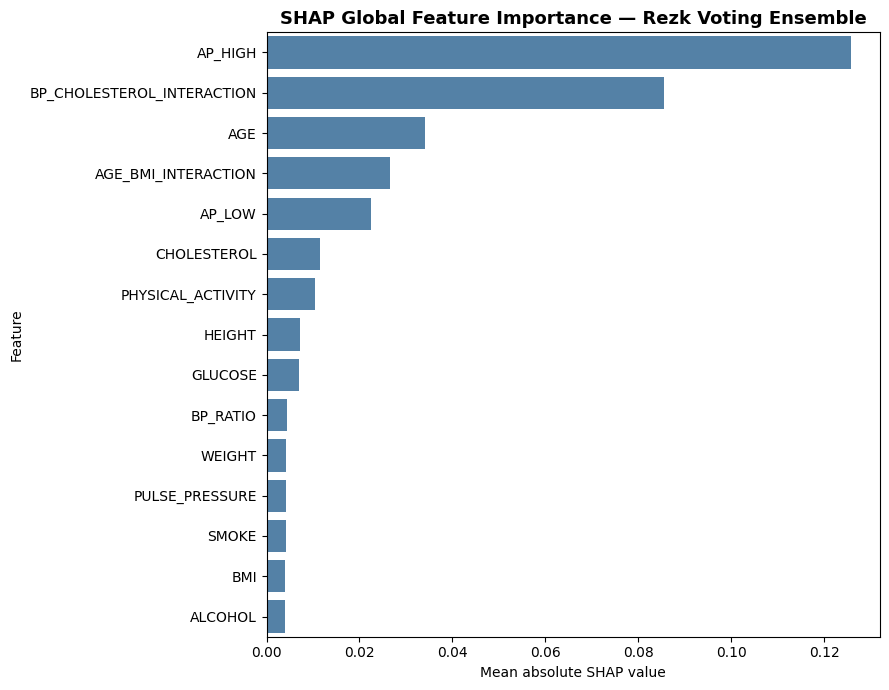

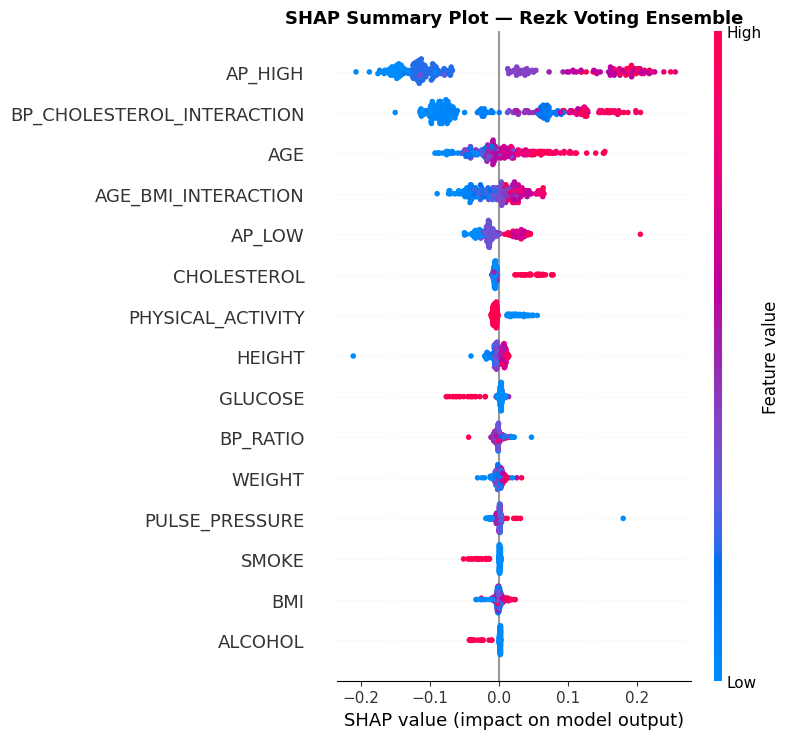

In [31]:
if "best_full_model" not in globals():
    raise NameError(
        "best_full_model is not defined. Run the hyperparameter optimization cell first. "
        "In the fixed notebook, that cell falls back safely to RandomizedSearchCV."
    )

def sample_dataframe(df_in, n, random_state=RANDOM_STATE):
    n = min(n, len(df_in))
    return df_in.sample(n=n, random_state=random_state) if len(df_in) > n else df_in.copy()

background_df = sample_dataframe(X_train_processed, BACKGROUND_SIZE)
shap_train_sample = sample_dataframe(X_train_processed, XAI_SAMPLE_SIZE)
shap_test_sample = sample_dataframe(X_test_processed, XAI_SAMPLE_SIZE)

positive_class_index = 1 if len(class_names) == 2 else 0

def voting_predict_proba_for_shap(data):
    data_df = pd.DataFrame(data, columns=feature_names)
    return best_full_model.predict_proba(data_df)

print(f"SHAP background shape: {background_df.shape}")
print(f"SHAP explanation sample shape: {shap_test_sample.shape}")

masker = shap.maskers.Independent(background_df)
shap_explainer = shap.Explainer(voting_predict_proba_for_shap, masker, algorithm="permutation")

max_evals = max(2 * len(feature_names) + 1, 101)
print(f"Using max_evals={max_evals} for SHAP permutation explanations.")

shap_values_test = shap_explainer(shap_test_sample, max_evals=max_evals, batch_size=50)

if len(shap_values_test.values.shape) == 3:
    shap_matrix_test = shap_values_test.values[:, :, positive_class_index]
else:
    shap_matrix_test = shap_values_test.values

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_matrix_test).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top SHAP features:")
display(shap_importance.head(15))
shap_importance.to_csv(OUTPUT_DIR / "shap_global_feature_importance.csv", index=False)

plt.figure(figsize=(9, 7))
sns.barplot(data=shap_importance.head(15), x="mean_abs_shap", y="feature", color="steelblue")
plt.title("SHAP Global Feature Importance — Rezk Voting Ensemble", fontsize=13, weight="bold")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_global_importance_bar.png", dpi=200, bbox_inches="tight")
plt.show()

try:
    shap.summary_plot(shap_matrix_test, shap_test_sample, feature_names=feature_names, show=False, max_display=15)
    plt.title("SHAP Summary Plot — Rezk Voting Ensemble", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "shap_summary_plot.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as exc:
    print(f"SHAP summary plot could not be rendered: {exc}")


Local SHAP explanation for original row index: 38875


,feature,feature_value,shap_value,abs_shap_value
4,AP_HIGH,1.393423,0.206427,0.206427
16,BP_CHOLESTEROL_INTERACTION,-0.257439,0.064352,0.064352
5,AP_LOW,0.887864,0.035554,0.035554
0,AGE,0.988418,0.027440,0.027440
2,HEIGHT,-1.028556,-0.006694,0.006694
10,PHYSICAL_ACTIVITY,0.495532,-0.004050,0.004050
15,AGE_BMI_INTERACTION,-0.300490,-0.003506,0.003506
14,BP_RATIO,0.690803,0.003161,0.003161
7,GLUCOSE,-0.394439,0.003104,0.003104
12,BMI,-0.818965,0.003038,0.003038


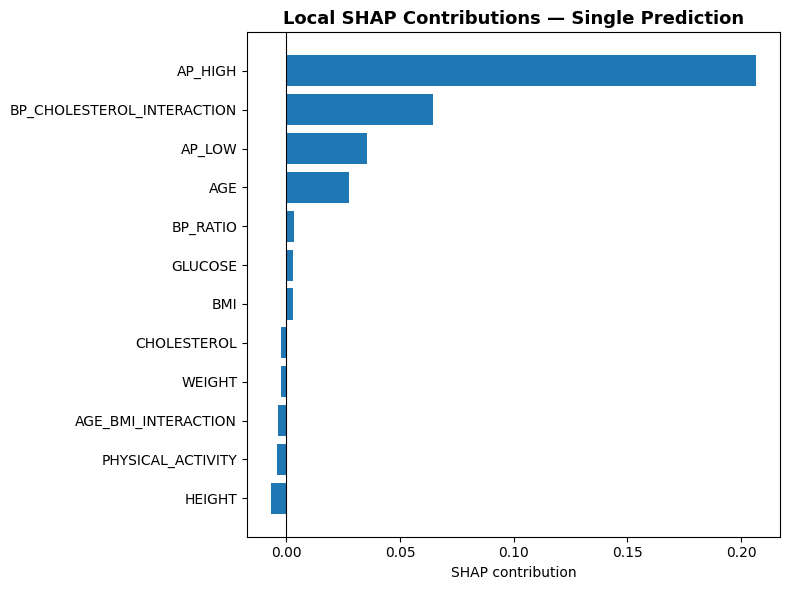

In [32]:
local_index = shap_test_sample.index[0]
local_position = 0

local_shap_df = pd.DataFrame({
    "feature": feature_names,
    "feature_value": shap_test_sample.iloc[local_position].values,
    "shap_value": shap_matrix_test[local_position],
    "abs_shap_value": np.abs(shap_matrix_test[local_position]),
}).sort_values("abs_shap_value", ascending=False)

print(f"Local SHAP explanation for original row index: {local_index}")
display(local_shap_df.head(15))
local_shap_df.to_csv(OUTPUT_DIR / "shap_local_explanation_instance.csv", index=False)

try:
    top_local = local_shap_df.head(12).sort_values("shap_value")
    plt.figure(figsize=(8, 6))
    plt.barh(top_local["feature"], top_local["shap_value"])
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Local SHAP Contributions — Single Prediction", fontsize=13, weight="bold")
    plt.xlabel("SHAP contribution")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "shap_local_contributions.png", dpi=200, bbox_inches="tight")
    plt.show()
except Exception as exc:
    print(f"Local SHAP plot could not be rendered: {exc}")

## 14. XAI technique 2 — LIME local explanation


LIME explanation for one test instance:


,feature_rule,lime_weight
0,AP_HIGH <= -0.39,-0.232982
1,BP_CHOLESTEROL_INTERACTION <= -0.57,-0.152257
2,AGE > 0.69,0.103483
3,ALCOHOL <= -0.24,0.057404
4,AP_LOW <= -0.14,-0.046851
5,CHOLESTEROL <= -0.54,-0.036439
6,-0.13 < AGE_BMI_INTERACTION <= 0.50,0.034320
7,SMOKE <= -0.31,0.031893
8,HEIGHT <= -0.66,-0.019422
9,WEIGHT <= -0.64,-0.016867


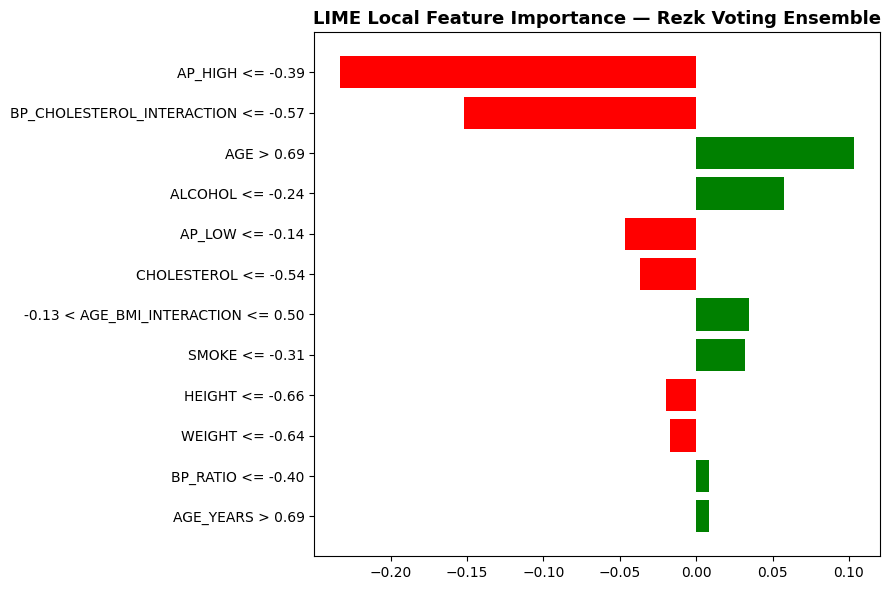

In [33]:
if "best_full_model" not in globals():
    raise NameError("best_full_model is not defined. Run the optimization/evaluation cells before LIME.")

lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)


def lime_predict_proba(data):
    """LIME passes NumPy arrays; convert them back to DataFrame to preserve feature names."""
    data_df = pd.DataFrame(data, columns=feature_names)
    return best_full_model.predict_proba(data_df)


lime_instance_position = 0
lime_instance = X_test_processed.iloc[lime_instance_position].values
lime_exp = lime_explainer.explain_instance(
    data_row=lime_instance,
    predict_fn=lime_predict_proba,
    num_features=min(12, len(feature_names)),
)

lime_list = lime_exp.as_list()
lime_df = pd.DataFrame(lime_list, columns=["feature_rule", "lime_weight"])
print("LIME explanation for one test instance:")
display(lime_df)
lime_df.to_csv(OUTPUT_DIR / "lime_local_explanation.csv", index=False)

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(9, 6)
plt.title("LIME Local Feature Importance — Rezk Voting Ensemble", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lime_local_explanation.png", dpi=200, bbox_inches="tight")
plt.show()


## 15. XAI technique 3 — Permutation importance


Top permutation-important features:


,feature,importance_mean,importance_std
0,AP_HIGH,0.090240,0.002383
1,BP_CHOLESTEROL_INTERACTION,0.028055,0.002402
2,AGE,0.012314,0.001442
3,AGE_BMI_INTERACTION,0.005936,0.001111
4,PHYSICAL_ACTIVITY,0.003270,0.000817
5,AP_LOW,0.002445,0.001198
6,BMI,0.002141,0.000473
7,WEIGHT,0.001600,0.000666
8,CHOLESTEROL,0.001338,0.000626
9,SMOKE,0.001326,0.000575


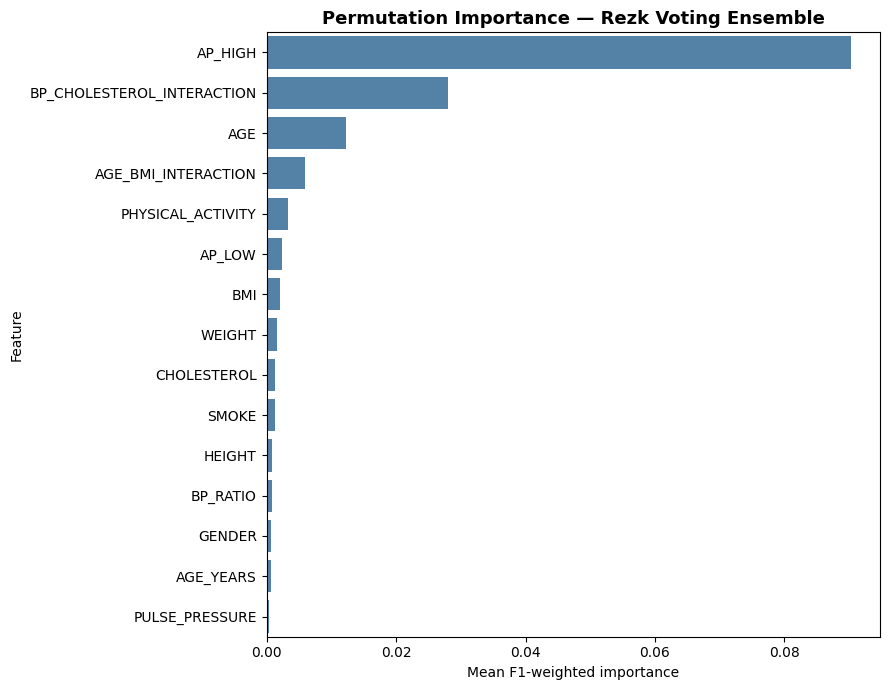

In [34]:
perm_result = permutation_importance(
    best_full_model,
    X_test_processed,
    y_test,
    n_repeats=8 if FAST_MODE else 15,
    random_state=RANDOM_STATE,
    scoring="f1_weighted",
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Top permutation-important features:")
display(perm_df.head(15))
perm_df.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)

plt.figure(figsize=(9, 7))
sns.barplot(data=perm_df.head(15), x="importance_mean", y="feature", color="steelblue")
plt.title("Permutation Importance — Rezk Voting Ensemble", fontsize=13, weight="bold")
plt.xlabel("Mean F1-weighted importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "permutation_importance_bar.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. XAI technique 4 — Partial Dependence and ICE plots


PDP/ICE features: ['AP_HIGH', 'BP_CHOLESTEROL_INTERACTION', 'AGE']


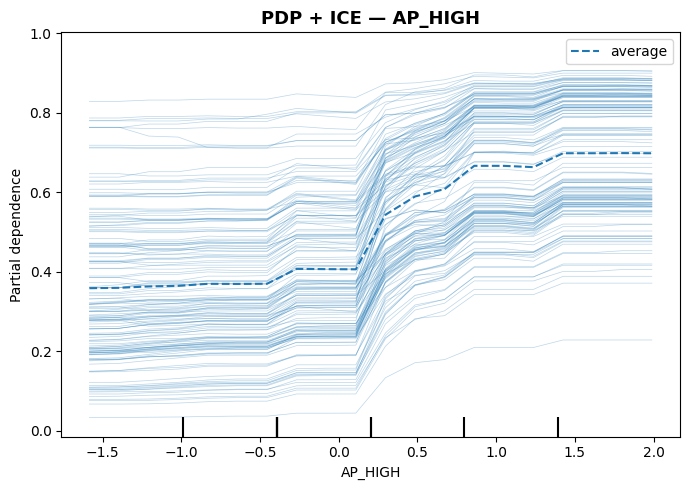

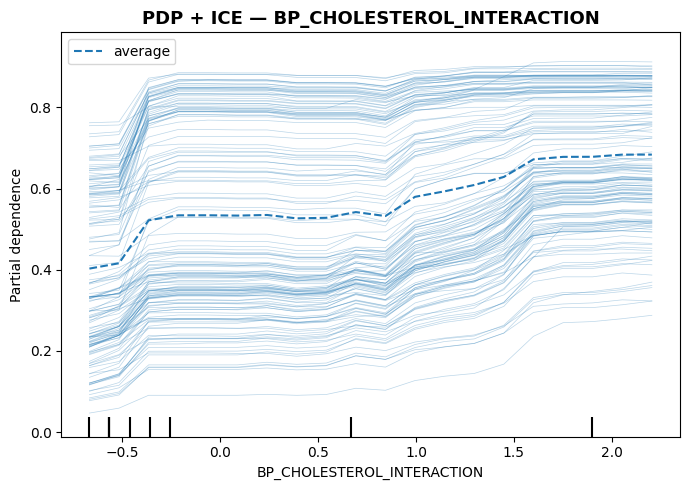

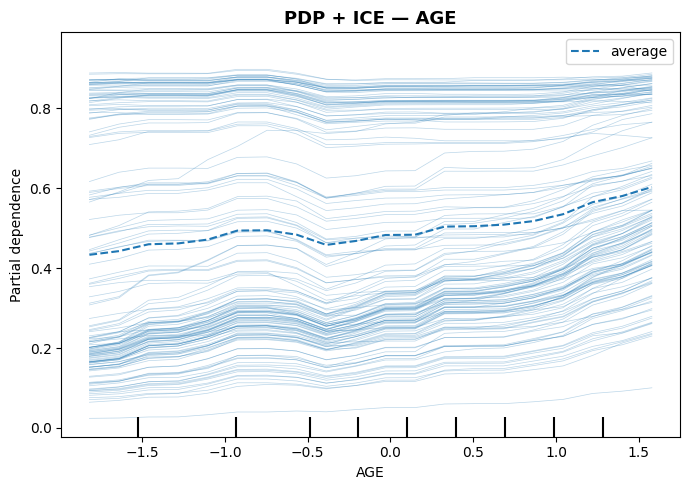

In [35]:
if "shap_importance" in globals() and not shap_importance.empty:
    pdp_features = shap_importance["feature"].head(PDP_FEATURE_COUNT).tolist()
else:
    pdp_features = perm_df["feature"].head(PDP_FEATURE_COUNT).tolist()

print(f"PDP/ICE features: {pdp_features}")

for feature in pdp_features:
    try:
        fig, ax = plt.subplots(figsize=(7, 5))
        kwargs = {
            "estimator": best_full_model,
            "X": X_test_processed,
            "features": [feature],
            "kind": "both",
            "subsample": min(150, len(X_test_processed)),
            "grid_resolution": 20,
            "ax": ax,
            "random_state": RANDOM_STATE,
        }
        if len(class_names) == 2:
            kwargs["target"] = 1
        PartialDependenceDisplay.from_estimator(**kwargs)
        plt.title(f"PDP + ICE — {feature}", fontsize=13, weight="bold")
        plt.tight_layout()
        safe_feature_name = re.sub(r"[^a-zA-Z0-9_]+", "_", feature)[:80]
        plt.savefig(OUTPUT_DIR / f"pdp_ice_{safe_feature_name}.png", dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as exc:
        print(f"Could not create PDP/ICE for {feature}: {exc}")

## 17. XAI-guided feature selection and compact model retraining


Selected 12 features using SHAP:
- AP_HIGH
- BP_CHOLESTEROL_INTERACTION
- AGE
- AGE_BMI_INTERACTION
- AP_LOW
- CHOLESTEROL
- PHYSICAL_ACTIVITY
- HEIGHT
- GLUCOSE
- BP_RATIO
- WEIGHT
- PULSE_PRESSURE


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Average_Precision
0,Rezk Voting Ensemble — XAI-selected 12 features,0.73061,0.732116,0.73061,0.729983,0.798755,0.782553


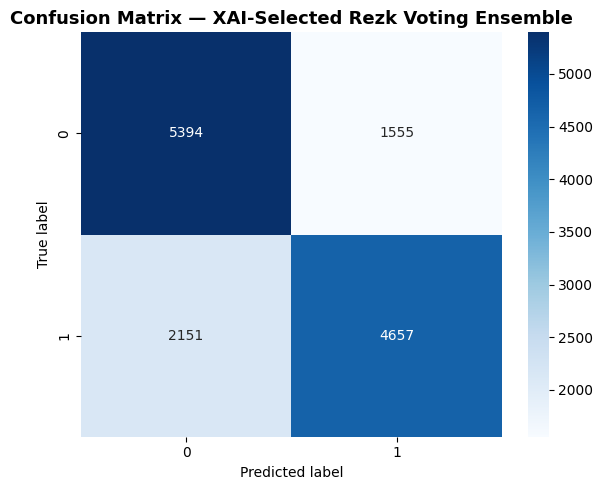

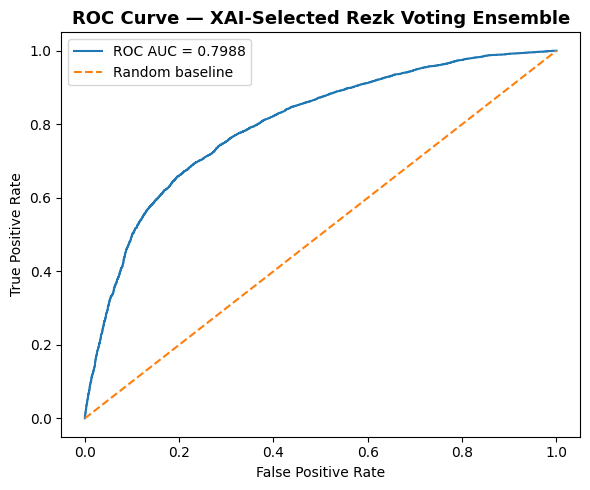

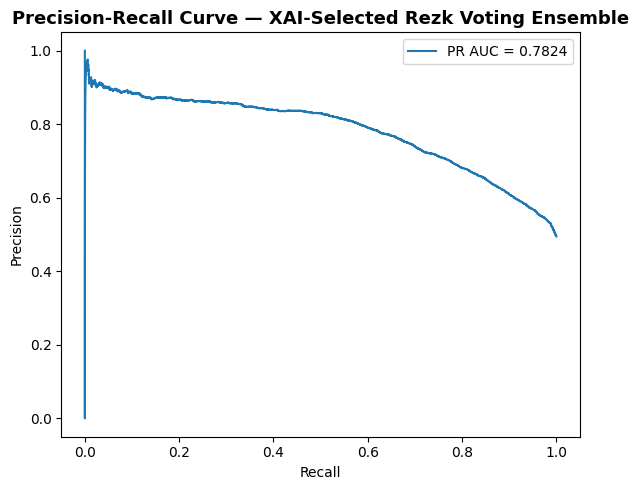

In [36]:
if "shap_importance" in globals() and not shap_importance.empty:
    selected_features = shap_importance["feature"].head(min(TOP_K_XAI_FEATURES, len(feature_names))).tolist()
    selection_source = "SHAP"
else:
    selected_features = perm_df["feature"].head(min(TOP_K_XAI_FEATURES, len(feature_names))).tolist()
    selection_source = "Permutation Importance"

print(f"Selected {len(selected_features)} features using {selection_source}:")
for f in selected_features:
    print("-", f)

X_train_selected = X_train_processed[selected_features]
X_test_selected = X_test_processed[selected_features]

selected_model = clone(best_full_model)
selected_model.fit(X_train_selected, y_train)

selected_model_metrics = evaluate_model(
    selected_model,
    X_test_selected,
    y_test,
    model_name=f"Rezk Voting Ensemble — XAI-selected {len(selected_features)} features",
)

display(pd.DataFrame([selected_model_metrics]))

plot_confusion_matrix(
    selected_model,
    X_test_selected,
    y_test,
    title="Confusion Matrix — XAI-Selected Rezk Voting Ensemble",
    filename="selected_voting_confusion_matrix.png",
)
plot_roc_pr_curves(
    selected_model,
    X_test_selected,
    y_test,
    model_name="XAI-Selected Rezk Voting Ensemble",
    prefix="selected_voting",
)

## 18. Full-feature vs XAI-selected model comparison


Full-feature vs XAI-selected comparison:


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Average_Precision
0,Rezk Voting Ensemble — Full Features,0.73250,0.734011,0.73250,0.731881,0.799852,0.782932
1,Rezk Voting Ensemble — XAI-selected 12 features,0.73061,0.732116,0.73061,0.729983,0.798755,0.782553


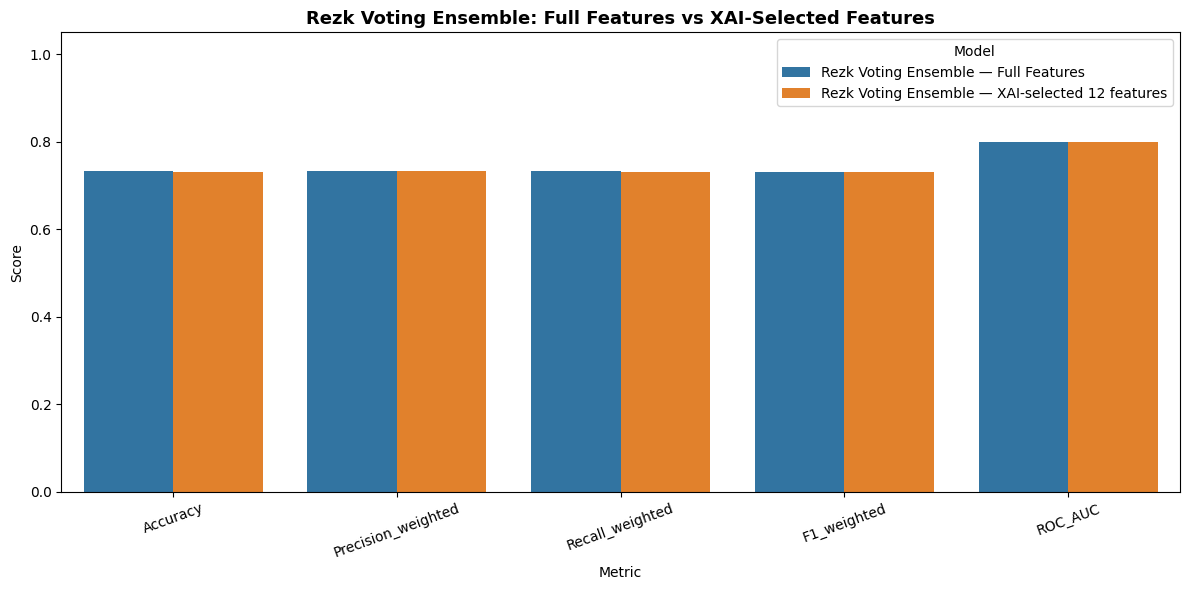

In [37]:
comparison_df = pd.DataFrame([full_model_metrics, selected_model_metrics])
metric_cols = [c for c in comparison_df.columns if c != "Model"]

print("Full-feature vs XAI-selected comparison:")
display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "full_vs_xai_selected_comparison.csv", index=False)

plot_metrics = ["Accuracy", "Precision_weighted", "Recall_weighted", "F1_weighted"]
if "ROC_AUC" in comparison_df.columns:
    plot_metrics.append("ROC_AUC")
elif "ROC_AUC_OVR" in comparison_df.columns:
    plot_metrics.append("ROC_AUC_OVR")

comparison_long = comparison_df.melt(id_vars="Model", value_vars=plot_metrics, var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Rezk Voting Ensemble: Full Features vs XAI-Selected Features", fontsize=13, weight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "full_vs_xai_selected_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

## 19. Additional reliability analysis — calibration curve


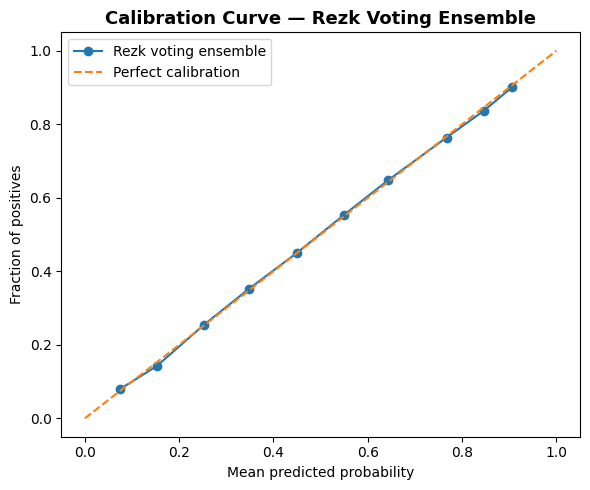

In [38]:
if len(class_names) == 2:
    y_proba_full = best_full_model.predict_proba(X_test_processed)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_proba_full, n_bins=10)

    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label="Rezk voting ensemble")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration Curve — Rezk Voting Ensemble", fontsize=13, weight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "calibration_curve.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Calibration curve helper is configured for binary classification only. Skipping.")

## 20. XAI method comparison table


In [39]:
xai_comparison = pd.DataFrame([
    {
        "XAI Method": "SHAP",
        "Scope": "Global + local",
        "Main Output": "Feature contribution values based on Shapley values",
        "Strength": "Strong theoretical foundation and clear global ranking",
        "Limitation": "Can be computationally expensive for model-agnostic voting ensembles",
    },
    {
        "XAI Method": "LIME",
        "Scope": "Local",
        "Main Output": "Interpretable local surrogate explanation for one prediction",
        "Strength": "Useful for explaining a single patient-level prediction",
        "Limitation": "Local explanations may vary depending on perturbation settings",
    },
    {
        "XAI Method": "Permutation Importance",
        "Scope": "Global",
        "Main Output": "Performance drop after shuffling each feature",
        "Strength": "Directly evaluates the trained model as a black box",
        "Limitation": "Can underestimate correlated features",
    },
    {
        "XAI Method": "PDP/ICE",
        "Scope": "Global trend + individual curves",
        "Main Output": "Relationship between feature values and predicted disease risk",
        "Strength": "Clinically intuitive risk-trend visualization",
        "Limitation": "Assumes feature interventions are meaningful; correlated features can distort interpretation",
    },
])

display(xai_comparison)
xai_comparison.to_csv(OUTPUT_DIR / "xai_method_comparison.csv", index=False)

,XAI Method,Scope,Main Output,Strength,Limitation
0,SHAP,Global + local,Feature contribution values based on Shapley v...,Strong theoretical foundation and clear global...,Can be computationally expensive for model-agn...
1,LIME,Local,Interpretable local surrogate explanation for ...,Useful for explaining a single patient-level p...,Local explanations may vary depending on pertu...
2,Permutation Importance,Global,Performance drop after shuffling each feature,Directly evaluates the trained model as a blac...,Can underestimate correlated features
3,PDP/ICE,Global trend + individual curves,Relationship between feature values and predic...,Clinically intuitive risk-trend visualization,Assumes feature interventions are meaningful; ...


## 21. Save model artifacts and run summary


In [40]:
model_bundle = {
    "paper": "Rezk et al. (2024) XAI-Augmented Voting Ensemble",
    "data_path": DATA_PATH,
    "target_column": TARGET_COLUMN_CLEAN,
    "preprocessor": preprocessor,
    "label_encoder": label_encoder,
    "feature_names": feature_names,
    "class_names": class_names,
    "full_model": best_full_model,
    "selected_features": selected_features,
    "selected_model": selected_model,
    "search_method": search_method,
    "best_params": getattr(search, "best_params_", {}),
    "full_model_metrics": full_model_metrics,
    "selected_model_metrics": selected_model_metrics,
}

model_path = OUTPUT_DIR / "rezk_2024_xai_augmented_voting_ensemble.joblib"
joblib.dump(model_bundle, model_path)
print(f"Saved model bundle to: {model_path}")

summary = {
    "paper": model_bundle["paper"],
    "data_path": str(DATA_PATH),
    "target_column": TARGET_COLUMN_CLEAN,
    "rows_after_cleaning": int(df_model.shape[0]),
    "original_features_after_engineering": int(X.shape[1]),
    "processed_features": int(len(feature_names)),
    "selected_features_count": int(len(selected_features)),
    "selected_features": selected_features,
    "class_names": class_names,
    "search_method": search_method,
    "best_cv_score": float(getattr(search, "best_score_", np.nan)),
    "best_params": {k: str(v) for k, v in getattr(search, "best_params_", {}).items()},
    "full_model_metrics": {k: (float(v) if isinstance(v, (int, float, np.floating)) else str(v)) for k, v in full_model_metrics.items()},
    "selected_model_metrics": {k: (float(v) if isinstance(v, (int, float, np.floating)) else str(v)) for k, v in selected_model_metrics.items()},
    "xai_methods": ["SHAP", "LIME", "Permutation Importance", "PDP/ICE"],
}

with open(OUTPUT_DIR / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

print(f"Saved run summary to: {OUTPUT_DIR / 'run_summary.json'}")


Saved model bundle to: rezk_2024_outputs/rezk_2024_xai_augmented_voting_ensemble.joblib
Saved run summary to: rezk_2024_outputs/run_summary.json
